<a href="https://www.kaggle.com/code/abdulqadirds/customer-churn-prediction-ipynb?scriptVersionId=320401585" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# SECTION 1: IMPORTS

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
 
import warnings
warnings.filterwarnings("ignore")
 
print("All libraries imported successfully!")

All libraries imported successfully!


# SECTION 2: LOAD DATASET

In [2]:
# loading dataset
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (7043, 21)


In [4]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

In [5]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
print("\nData types:")
print(df.dtypes)


Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
# Basic statistics
print("\nBasic Statistics:")
print(df.describe())


Basic Statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [8]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
# Target variable distribution ---
print("\nChurn Value Counts:")
print(df["Churn"].value_counts())


Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


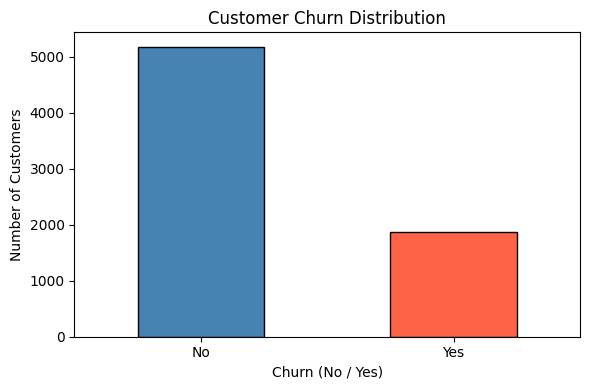

Saved: plot1_churn_distribution.png


In [10]:
# Plot 1: Churn distribution (bar chart)
plt.figure(figsize=(6, 4))
df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (No / Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot1_churn_distribution.png")
plt.show()
print("Saved: plot1_churn_distribution.png")

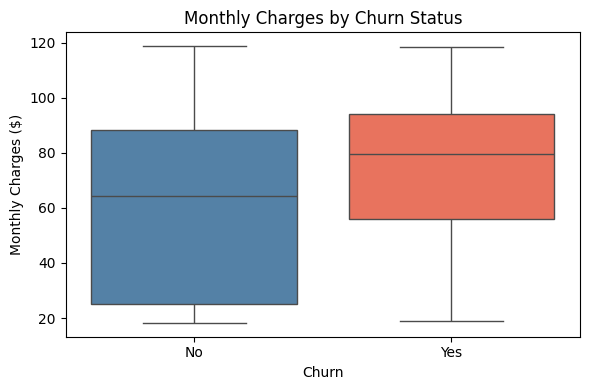

Saved: plot2_monthly_charges_boxplot.png


In [11]:
# Plot 2: Monthly Charges by Churn status (box plot)
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["steelblue", "tomato"])
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("plot2_monthly_charges_boxplot.png")
plt.show()
print("Saved: plot2_monthly_charges_boxplot.png")

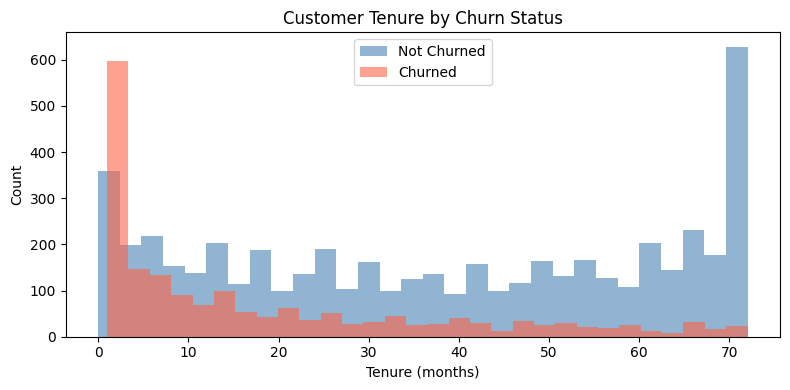

Saved: plot3_tenure_histogram.png


In [12]:
# Plot 3: Tenure distribution by churn (histogram)
plt.figure(figsize=(8, 4))
df[df["Churn"] == "No"]["tenure"].plot(kind="hist", bins=30, alpha=0.6, color="steelblue", label="Not Churned")
df[df["Churn"] == "Yes"]["tenure"].plot(kind="hist", bins=30, alpha=0.6, color="tomato", label="Churned")
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_tenure_histogram.png")
plt.show()
print("Saved: plot3_tenure_histogram.png")

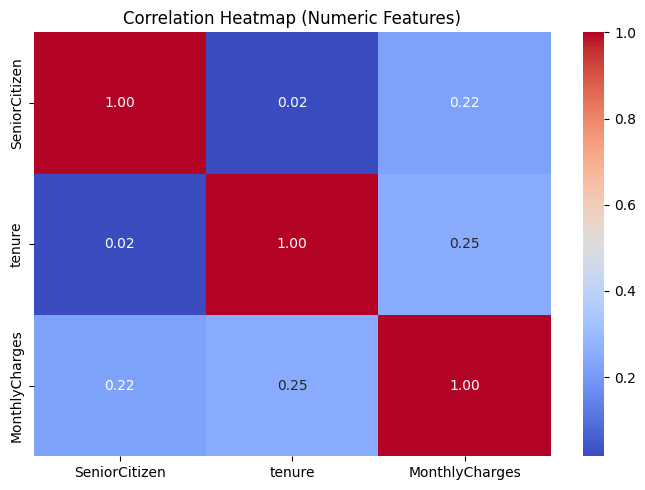

Saved: plot4_correlation_heatmap.png


In [13]:
# Plot 4: Correlation heatmap (numeric columns only)
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=["float64", "int64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("plot4_correlation_heatmap.png")
plt.show()
print("Saved: plot4_correlation_heatmap.png")

# SECTION 4: DATA CLEANING & PREPROCESSING

In [14]:
# Drop customerID (unique identifier, not useful for ML) ---
df.drop(columns=["customerID"], inplace=True)

In [15]:
# Fix TotalCharges column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [16]:
print("\nMissing values after TotalCharges fix:")
print(df.isnull().sum())


Missing values after TotalCharges fix:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [17]:
# Handle missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print("Missing values handled. Total nulls:", df.isnull().sum().sum())

Missing values handled. Total nulls: 0


In [18]:
# Encode TARGET column: Churn (Yes → 1, No → 0) 
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print("\nTarget encoded. Churn (1=Yes, 0=No):", df["Churn"].value_counts().to_dict())


Target encoded. Churn (1=Yes, 0=No): {0: 5174, 1: 1869}


In [19]:
# Identify categorical and numerical columns 
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_cols.remove("Churn")  # remove target from feature list
 
print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [20]:
# Encode categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f"  Encoded '{col}'")
 
print("All categorical columns encoded!")

  Encoded 'gender'
  Encoded 'Partner'
  Encoded 'Dependents'
  Encoded 'PhoneService'
  Encoded 'MultipleLines'
  Encoded 'InternetService'
  Encoded 'OnlineSecurity'
  Encoded 'OnlineBackup'
  Encoded 'DeviceProtection'
  Encoded 'TechSupport'
  Encoded 'StreamingTV'
  Encoded 'StreamingMovies'
  Encoded 'Contract'
  Encoded 'PaperlessBilling'
  Encoded 'PaymentMethod'
All categorical columns encoded!


In [21]:
# Separate features (X) and target (y) 
X = df.drop(columns=["Churn"])   # all columns except Churn
y = df["Churn"]                  # only Churn column
 
print("\nFeatures shape:", X.shape)
print("Target shape  :", y.shape)


Features shape: (7043, 19)
Target shape  : (7043,)


# SECTION 5: TRAIN-TEST SPLIT

In [22]:
# Split: 80% training, 20% testing
# random_state=42 makes results reproducible (same split every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"\nTrain size: {X_train.shape[0]} rows")
print(f"Test size : {X_test.shape[0]} rows")


Train size: 5634 rows
Test size : 1409 rows


# SECTION 6: FEATURE SCALING

In [23]:
# StandardScaler: transforms data so mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform training data
X_test_scaled  = scaler.transform(X_test)         # only transform test data
 
print("Features scaled using StandardScaler")
print("Example: first row before scaling:", X_train.iloc[0].values[:5])
print("Example: first row after  scaling:", X_train_scaled[0][:5].round(2))


Features scaled using StandardScaler
Example: first row before scaling: [ 1.  0.  0.  0. 35.]
Example: first row after  scaling: [ 0.99 -0.44 -0.97 -0.65  0.1 ]


# SECTION 7: MODEL TRAINING

In [24]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print("\nLogistic Regression trained!")


Logistic Regression trained!


In [25]:
# Model 2: K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
print("KNN (k=7) trained!")

KNN (k=7) trained!


# SECTION 8: MODEL EVALUATION

In [26]:
# Model Evaluations
def evaluate_model(name, y_true, y_pred):
    """
    Prints evaluation metrics for a classification model.
    Returns a dict with all metrics for easy comparison later.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
 
    print(f"\n{'='*45}")
    print(f" {name} Evaluation")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Not Churned", "Churned"]))
 
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

In [27]:
# Evaluate both models
lr_metrics  = evaluate_model("Logistic Regression", y_test, lr_preds)
knn_metrics = evaluate_model("KNN (k=7)",           y_test, knn_preds)


 Logistic Regression Evaluation
  Accuracy  : 0.7991  (79.91%)
  Precision : 0.6426
  Recall    : 0.5481
  F1-Score  : 0.5916

  Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.84      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


 KNN (k=7) Evaluation
  Accuracy  : 0.7537  (75.37%)
  Precision : 0.5387
  Recall    : 0.5027
  F1-Score  : 0.5201

  Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.82      0.84      0.83      1035
     Churned       0.54      0.50      0.52       374

    accuracy                           0.75      1409
   macro avg       0.68      0.67      0.68      1409
weighted avg       0.75      0.75      0.75      1409



# SECTION 9: CONFUSION MATRICES

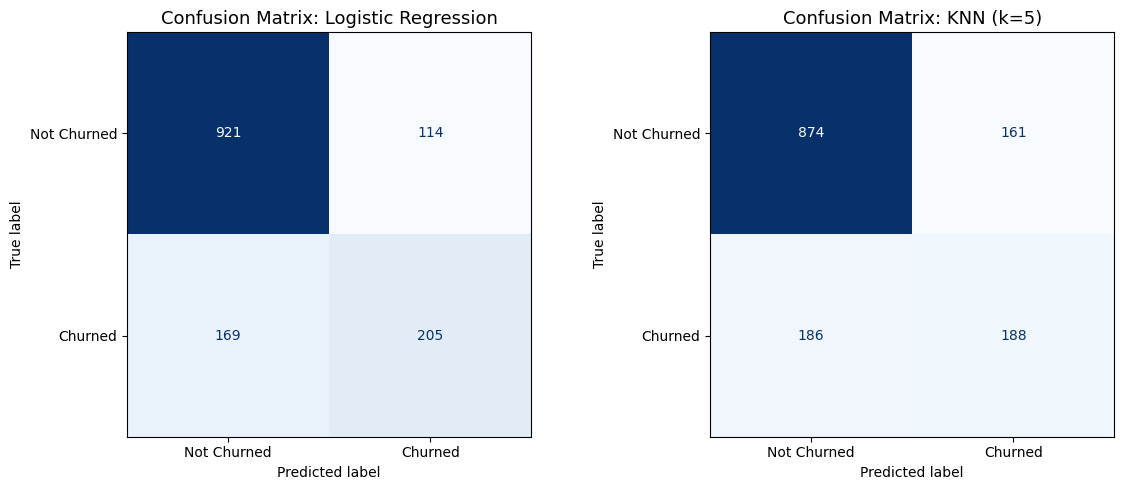

Saved: plot5_confusion_matrices.png


In [28]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, preds, name in zip(axes,
                            [lr_preds, knn_preds],
                            ["Logistic Regression", "KNN (k=5)"]):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Not Churned", "Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix: {name}", fontsize=13)
 
plt.tight_layout()
plt.savefig("plot5_confusion_matrices.png")
plt.show()
print("Saved: plot5_confusion_matrices.png")

# SECTION 10: MODEL COMPARISON TABLE

In [29]:
results_df = pd.DataFrame([lr_metrics, knn_metrics])
results_df = results_df.set_index("Model")
results_df = results_df.round(4)
 
print("\n" + "="*55)
print("MODEL COMPARISON SUMMARY")
print("="*55)
print(results_df.to_string())


MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.7991     0.6426  0.5481    0.5916
KNN (k=7)              0.7537     0.5387  0.5027    0.5201


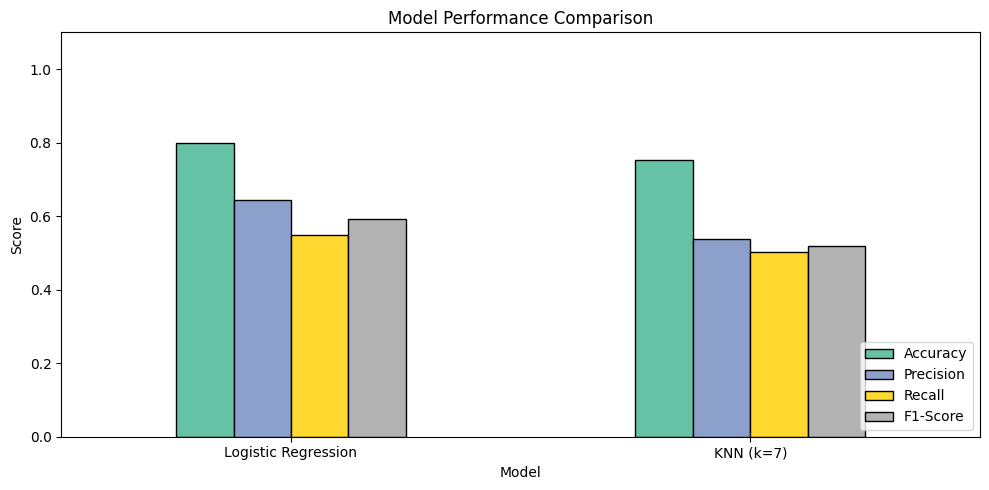

Saved: plot6_model_comparison.png


In [30]:
# Bar chart comparing all metrics side by side
results_df.plot(kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="black")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plot6_model_comparison.png")
plt.show()
print("Saved: plot6_model_comparison.png")

# SECTION 11: OVERFITTING VS UNDERFITTING

In [31]:
print("\n" + "="*55)
print("OVERFITTING CHECK: Train vs Test Accuracy")
print("="*55)


OVERFITTING CHECK: Train vs Test Accuracy


In [32]:
for model, name in [(lr_model, "Logistic Regression"), (knn_model, "KNN (k=5)")]:
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled, y_test)
    gap       = train_acc - test_acc
 
    print(f"\n  {name}")
    print(f"    Train Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"    Test  Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"    Gap            : {gap:.4f}")
 
    if gap > 0.05:
        print(f"Possible OVERFITTING — model may have memorized training data")
    elif train_acc < 0.75:
        print(f"Possible UNDERFITTING — model is too simple")
    else:
        print(f"GOOD FIT — model generalizes well")


  Logistic Regression
    Train Accuracy : 0.8040 (80.40%)
    Test  Accuracy : 0.7991 (79.91%)
    Gap            : 0.0049
GOOD FIT — model generalizes well

  KNN (k=5)
    Train Accuracy : 0.8202 (82.02%)
    Test  Accuracy : 0.7537 (75.37%)
    Gap            : 0.0665
Possible OVERFITTING — model may have memorized training data


# SECTION 12: KNN — FINDING THE BEST K

In [33]:
k_values   = list(range(1, 21))  # k from 1 to 20
train_accs = []
test_accs  = []
 
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_accs.append(model.score(X_train_scaled, y_train))
    test_accs.append(model.score(X_test_scaled, y_test))

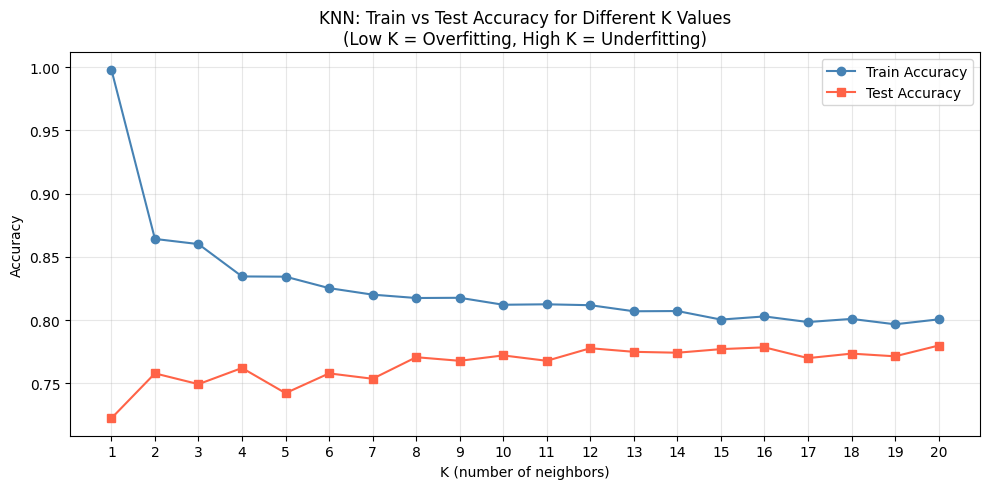

Saved: plot7_knn_k_selection.png

Best K value: 20 with Test Accuracy = 0.7800


In [34]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accs, marker="o", label="Train Accuracy", color="steelblue")
plt.plot(k_values, test_accs,  marker="s", label="Test Accuracy",  color="tomato")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Train vs Test Accuracy for Different K Values\n(Low K = Overfitting, High K = Underfitting)")
plt.legend()
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot7_knn_k_selection.png")
plt.show()
print("Saved: plot7_knn_k_selection.png")
 
best_k = k_values[test_accs.index(max(test_accs))]
print(f"\nBest K value: {best_k} with Test Accuracy = {max(test_accs):.4f}")

# SECTION 13: FEATURE IMPORTANCE (Logistic Regression)

In [35]:
feature_names = X.columns.tolist()
coefficients  = lr_model.coef_[0]
 
importance_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", key=abs, ascending=False).head(10)
 
print("\nTop 10 Most Important Features (Logistic Regression):")
print(importance_df.to_string(index=False))


Top 10 Most Important Features (Logistic Regression):
         Feature  Coefficient
          tenure    -1.212465
  MonthlyCharges     0.737153
        Contract    -0.605002
    TotalCharges     0.477248
    PhoneService    -0.291312
  OnlineSecurity    -0.246553
     TechSupport    -0.228527
PaperlessBilling     0.194977
 InternetService     0.177280
    OnlineBackup    -0.131782


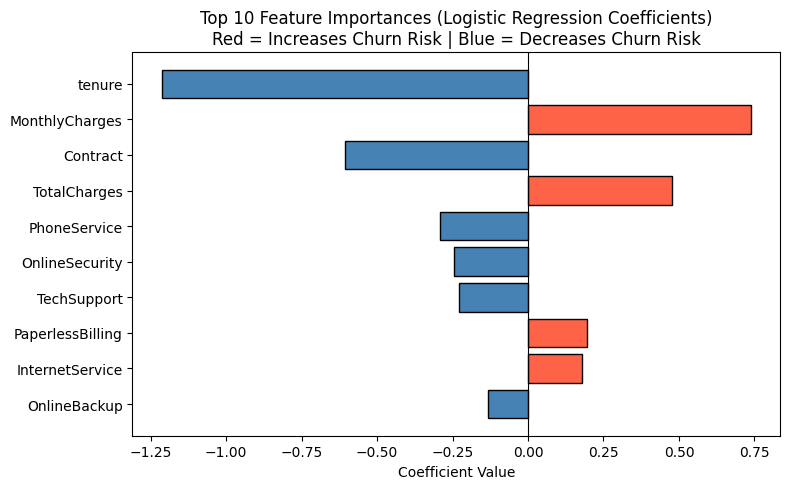

Saved: plot8_feature_importance.png


In [36]:
plt.figure(figsize=(8, 5))
colors = ["tomato" if c > 0 else "steelblue" for c in importance_df["Coefficient"]]
plt.barh(importance_df["Feature"], importance_df["Coefficient"], color=colors, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Top 10 Feature Importances (Logistic Regression Coefficients)\nRed = Increases Churn Risk | Blue = Decreases Churn Risk")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()
print("Saved: plot8_feature_importance.png")

# SECTION 14: FINAL SUMMARY

In [37]:
print("\n" + "="*55)
print("PROJECT 1 — FINAL SUMMARY")
print("="*55)
print("""
PROBLEM    : Predict if a telecom customer will churn (leave)
DATASET    : IBM Telco Customer Churn (~7,000 rows, 20 features)
TARGET     : Churn (1 = Yes, 0 = No)
 
STEPS DONE :
  1. Loaded and explored the dataset (EDA)
  2. Fixed TotalCharges (string → float)
  3. Handled missing values (median fill)
  4. Encoded categorical columns (LabelEncoder)
  5. Scaled features (StandardScaler)
  6. Split data: 80% train / 20% test
  7. Trained Logistic Regression and KNN models
  8. Evaluated using: Accuracy, Precision, Recall, F1, Confusion Matrix
  9. Checked for Overfitting (train vs test gap)
  10. Found best K for KNN using accuracy curve
  11. Analyzed feature importance from LR coefficients
 
MODELS     : Logistic Regression | KNN (k=5)
""")
print(results_df.to_string())
print("\nProject 1 Complete! All 8 plots saved.")


PROJECT 1 — FINAL SUMMARY

PROBLEM    : Predict if a telecom customer will churn (leave)
DATASET    : IBM Telco Customer Churn (~7,000 rows, 20 features)
TARGET     : Churn (1 = Yes, 0 = No)
 
STEPS DONE :
  1. Loaded and explored the dataset (EDA)
  2. Fixed TotalCharges (string → float)
  3. Handled missing values (median fill)
  4. Encoded categorical columns (LabelEncoder)
  5. Scaled features (StandardScaler)
  6. Split data: 80% train / 20% test
  7. Trained Logistic Regression and KNN models
  8. Evaluated using: Accuracy, Precision, Recall, F1, Confusion Matrix
  9. Checked for Overfitting (train vs test gap)
  10. Found best K for KNN using accuracy curve
  11. Analyzed feature importance from LR coefficients
 
MODELS     : Logistic Regression | KNN (k=5)

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.7991     0.6426  0.5481    0.5916
KNN (k=7)              0.7537     0.5387  0.50